[*********************100%***********************]  4 of 4 completed


загружено 751 дней для: AAPL, GE, HD, MSFT

 Годовая доходность (%):
  AAPL: 30.01%
  GE: 64.22%
  HD: 8.02%
  MSFT: 27.35%


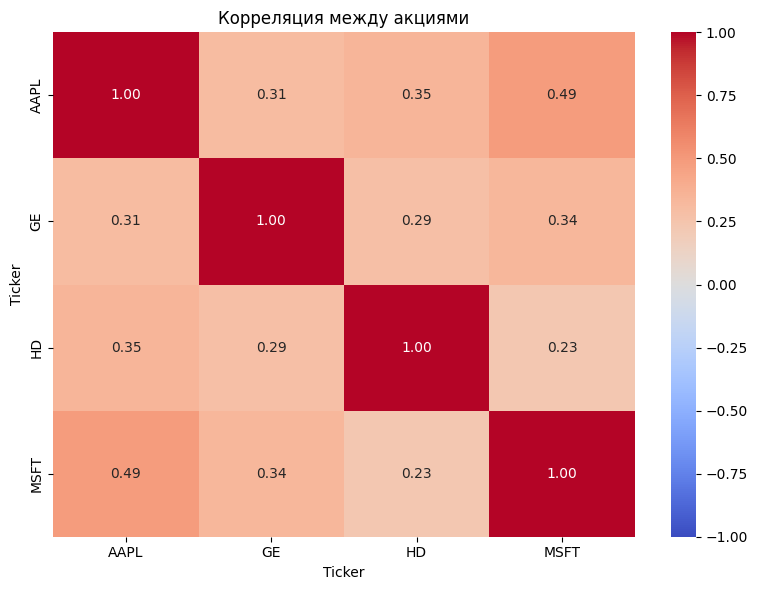

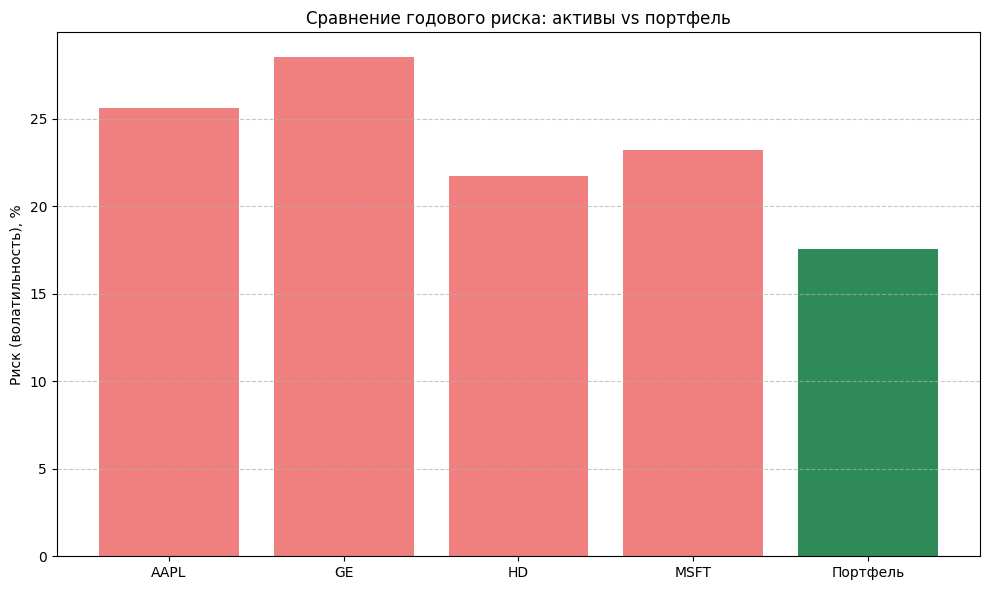


 Портфель (равные доли):
  Доходность: 32.40%
  Риск:       17.59%

 Исторический VaR (95%, 1 день): $16,067.52


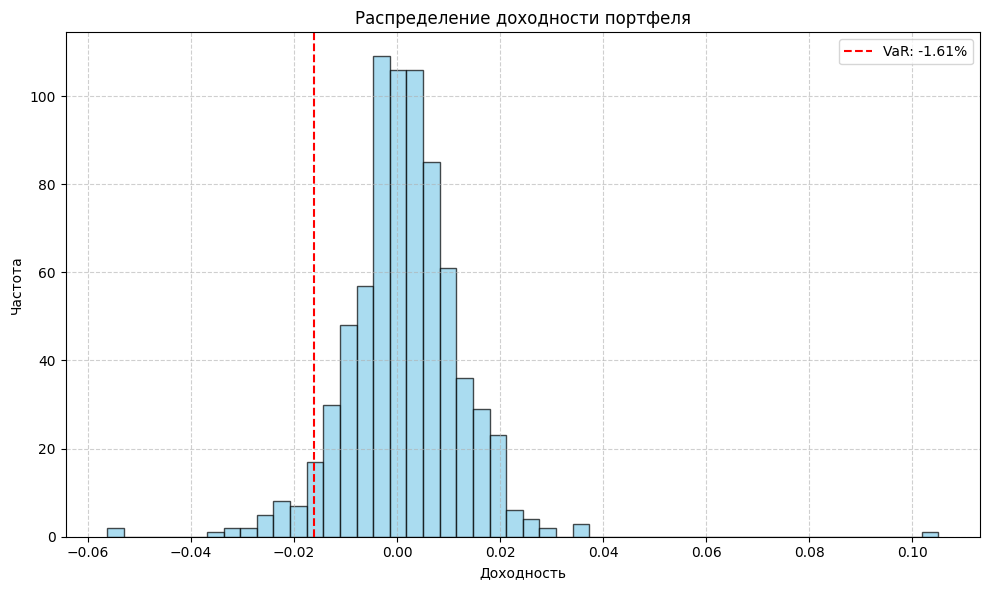


 Анализ завершён!


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


TICKERS = ['AAPL', 'MSFT', 'GE', 'HD']
START_DATE = '2023-01-01'
END_DATE = '2025-12-31'

#print("загрузка данных")
#далее следует вызов функции из библиотеки yfinance, которая получает истор данные с yahoo finance, в результате получаем таблицу с колонками
raw_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   #корректирует цены акции на "правильные"
)

if raw_data.empty: #проверяет все ли данные передались
    raise RuntimeError("данные не загружены, проверьте интернет и тикеры.") #обрывает программу

if 'Close' in raw_data.columns: #проверяет есть ли столбец Close в таблице - возврат одного актива
    prices = raw_data['Close']
#если запросили данные по нескольким активам - MultiIndex = термин в pfndas
elif isinstance(raw_data.columns, pd.MultiIndex) and 'Close' in raw_data.columns.levels[0]:
    prices = raw_data['Close']
#если данные передались некорректно
else: #не доджен не сработать
    prices = raw_data
    print("используем все доступные данные в исходном виде")

prices = prices.dropna() #очищает пустоту
if prices.empty:
    raise RuntimeError("цены пустые после очистки")

#приводим к единому формату DataFrame
if isinstance(prices, pd.Series):
    prices = prices.to_frame()

tickers = prices.columns.tolist()
print(f"загружено {len(prices)} дней для: {', '.join(tickers)}")


#ДОХОДНОСТЬ
returns = prices.pct_change().dropna()
annual_returns = returns.mean() * 252

print("\n Годовая доходность (%):")
for ticker in tickers:
    print(f"  {ticker}: {annual_returns[ticker] * 100:.2f}%")


#КОРРЕЛЯЦИЯ
corr_mat = returns.corr() #создает матрица корреляции+выдает новый датафрейм
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title('Корреляция между акциями')
plt.tight_layout()
plt.show()

weights = np.array([1 / len(tickers)] * len(tickers))
portfolio_return = np.dot(weights, annual_returns)      #функция, которая рассчитывает ожидаемую годовую доходность портфеля

cov_matrix = returns.cov()
annual_cov = cov_matrix * 252
portfolio_variance = np.dot(weights.T, np.dot(annual_cov, weights)) #дисперсия
portfolio_risk = np.sqrt(portfolio_variance) #стандартное отлонение = волатильность

#столбчатая диаграмма рисков
individual_risks = np.sqrt(returns.var() * 252)
plt.figure(figsize=(10, 6))
x_labels = tickers + ['Портфель'] #отмечаем на оси х все активы + сам портфель как отдельный инструмент
y_values = list(individual_risks * 100) + [portfolio_risk * 100]
colors = ['lightcoral'] * len(tickers) + ['seagreen']
plt.bar(x_labels, y_values, color=colors)
plt.title('Сравнение годового риска: активы vs портфель')
plt.ylabel('Риск (волатильность), %')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n Портфель (равные доли):")
print(f"  Доходность: {portfolio_return * 100:.2f}%")
print(f"  Риск:       {portfolio_risk * 100:.2f}%")


#VaR c вероятностью 95% мы не потеряем за день больше, чем $X
CONFIDENCE_LEVEL = 0.95 #задаем уровень порога
PORTFOLIO_VALUE = 1000000 #задаем стоимоcть портфеля
portfolio_daily_returns = returns.dot(weights) #вычисляем дневную доходность всего портфеля (средневзвешенную сумму)
alpha = 1 - CONFIDENCE_LEVEL
var_hist = np.percentile(portfolio_daily_returns, alpha * 100) #рассчитывает значение, при котором в 95% доходность будет выше данного значения
var_hist_amount = PORTFOLIO_VALUE * abs(var_hist) #переводим в деньги
print(f"\n Исторический VaR ({int(CONFIDENCE_LEVEL*100)}%, 1 день): ${var_hist_amount:,.2f}")

plt.figure(figsize=(10, 6))
plt.hist(portfolio_daily_returns, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(var_hist, color='red', linestyle='--', label=f'VaR: {var_hist:.2%}')
plt.title('Распределение доходности портфеля')
plt.xlabel('Доходность')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n Анализ завершён!")